# CivicRoute AI Course Assessment Starter Notebook

**Student name:**  Nora Eugenie Liverud
**Student number:**  118302
**GitHub repository:**  

This notebook supports the **revised structured-data assessment only**.

Use short, clearly labelled code sections. The assessment is not about producing a long notebook. Your aim is to create enough technical evidence to explain your decisions and results in the recorded video.

The notebook mainly supports:

- **Step 2:** Inspect and prepare the data with Pandas and NumPy.
- **Step 3:** Build one small TensorFlow/Keras model.
- **Step 4:** Record evidence for interpretation and explainability discussion.

GitHub workflow evidence, graph/GNN discussion and the final recommendation are demonstrated or discussed in the video rather than implemented here.


## Step 2: Inspect and prepare the data with Pandas and NumPy

### 2.1 Load and inspect the supplied dataset

Show the dataset shape, field names, data types, target-category counts and missing-value summary.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

# Recommended repository structure:
# project/
# ├── civicroute_assessment.ipynb
# └── data/
#     └── civic_requests_prepared.csv

DATA_PATH = Path("data/civic_requests_prepared.csv")

# If you keep the CSV beside the notebook instead, this fallback will find it.
if not DATA_PATH.exists():
    DATA_PATH = Path("civic_requests_prepared.csv")

df = pd.read_csv(DATA_PATH)

# TODO: Show:
# - shape
# - field names
# - data types
# - category counts
# - missing-value summary
# - a small preview of the data
print("Rows and columns:", df.shape)
df.info()
print("\nMissing values:")
print(df.isna().sum())

print("\nCategory counts:")
print(df["category_label"].value_counts())
df.head()


Rows and columns: (600, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   request_id                600 non-null    object 
 1   created_hour              600 non-null    int64  
 2   neighbourhood             600 non-null    object 
 3   channel                   596 non-null    object 
 4   urgency_level             600 non-null    object 
 5   recent_rain_flag          600 non-null    object 
 6   night_report_flag         600 non-null    object 
 7   repeat_report_count       600 non-null    int64  
 8   image_quality_score       590 non-null    float64
 9   nearby_asset_age_years    600 non-null    float64
 10  description_word_count    600 non-null    int64  
 11  previous_resolution_days  591 non-null    float64
 12  category_label            600 non-null    object 
dtypes: float64(3), int64(3), object(7)
me

,request_id,created_hour,neighbourhood,channel,urgency_level,recent_rain_flag,night_report_flag,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days,category_label
0,REQ-10001,18,North End,call_centre,medium,yes,yes,3,0.756,21.9,13,11.2,pothole
1,REQ-10002,8,Hillside,mobile_app,medium,yes,no,3,0.555,20.2,16,8.3,pothole
2,REQ-10003,20,Eastview,mobile_app,medium,no,yes,2,0.882,30.7,18,6.3,pothole
3,REQ-10004,11,South Park,mobile_app,medium,no,no,1,0.645,17.4,19,10.8,pothole
4,REQ-10005,20,Hillside,call_centre,medium,yes,yes,2,0.640,32.0,12,8.9,pothole


### 2.2 Select the fields and identify the target

Choose the fields you believe are relevant to the prototype. Exclude identifiers and avoid using any field simply because it is available. State the target column clearly.


In [2]:
TARGET = "category_label"

input_columns = [
    "created_hour",
    "channel",
    "urgency_level",
    "recent_rain_flag",
    "repeat_report_count",
    "image_quality_score",
    "nearby_asset_age_years",
    "description_word_count",
    "previous_resolution_days",
]

working_df = df[input_columns + [TARGET]].copy()

print("Input fields:", input_columns)
print("Target:", TARGET)
print("Working table shape:", working_df.shape)


Input fields: ['created_hour', 'channel', 'urgency_level', 'recent_rain_flag', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days']
Target: category_label
Working table shape: (600, 10)


### 2.3 Handle the small number of missing values

Use one sensible course-level method for the supplied missing values. Keep the code short and note why the method is appropriate so that you can explain the choice in your video.


In [3]:
from sklearn.model_selection import train_test_split

# Split before learning fill values or scaling statistics.
# 60% training, 20% validation, 20% test; preserve category proportions.
train_df, holdout_df = train_test_split(
    working_df, test_size=0.4, random_state=RANDOM_SEED,
    stratify=working_df[TARGET]
)
val_df, test_df = train_test_split(
    holdout_df, test_size=0.5, random_state=RANDOM_SEED,
    stratify=holdout_df[TARGET]
)
train_df, val_df, test_df = (
    train_df.copy(), val_df.copy(), test_df.copy()
)

numeric_columns = train_df[input_columns].select_dtypes(
    include="number"
).columns.tolist()
categorical_columns = train_df[input_columns].select_dtypes(
    include=["object", "category"]
).columns.tolist()

missing_before = working_df[input_columns].isna().sum()

# Learn replacements from training data only.
numeric_fill_values = train_df[numeric_columns].median()
categorical_fill_values = train_df[categorical_columns].mode().iloc[0]

for part in [train_df, val_df, test_df]:
    part[numeric_columns] = part[numeric_columns].fillna(numeric_fill_values)
    part[categorical_columns] = part[categorical_columns].fillna(
        categorical_fill_values
    )

missing_after = pd.concat(
    [train_df, val_df, test_df]
)[input_columns].isna().sum()
print(pd.DataFrame({"Before": missing_before, "After": missing_after}))

fill_values = pd.concat([numeric_fill_values, categorical_fill_values])
print("\nTraining-derived replacements for columns with missing values:")
print(fill_values[missing_before[missing_before > 0].index])
print("\nRows in training / validation / test:",
      len(train_df), len(val_df), len(test_df))


                          Before  After
created_hour                   0      0
channel                        4      0
urgency_level                  0      0
recent_rain_flag               0      0
repeat_report_count            0      0
image_quality_score           10      0
nearby_asset_age_years         0      0
description_word_count         0      0
previous_resolution_days       9      0

Training-derived replacements for columns with missing values:
channel                     mobile_app
image_quality_score              0.703
previous_resolution_days           7.9
dtype: object

Rows in training / validation / test: 360 120 120


### 2.4 Apply simple transformation or encoding

Prepare categorical data so that a neural network can use it. Use a short NumPy operation where it adds value, such as a vectorised numerical transformation or inspection of an array.


In [4]:
# Turn categorical inputs into separate 0/1 columns.
train_encoded = pd.get_dummies(
    train_df[input_columns], columns=categorical_columns, dtype=np.float32
)
val_encoded = pd.get_dummies(
    val_df[input_columns], columns=categorical_columns, dtype=np.float32
).reindex(columns=train_encoded.columns, fill_value=0)
test_encoded = pd.get_dummies(
    test_df[input_columns], columns=categorical_columns, dtype=np.float32
).reindex(columns=train_encoded.columns, fill_value=0)

# Use NumPy to put numerical inputs on comparable scales.
# Learn the mean and spread from training data only.
training_numbers = train_df[numeric_columns].to_numpy(dtype=np.float32)
numeric_mean = np.mean(training_numbers, axis=0)
numeric_std = np.std(training_numbers, axis=0)
numeric_std = np.where(numeric_std == 0, 1.0, numeric_std)

for prepared in [train_encoded, val_encoded, test_encoded]:
    values = prepared[numeric_columns].to_numpy(dtype=np.float32)
    prepared[numeric_columns] = (values - numeric_mean) / numeric_std

# Give each target category a consistent integer label.
class_names = sorted(train_df[TARGET].unique().tolist())
class_to_id = {name: number for number, name in enumerate(class_names)}

X_train = train_encoded.to_numpy(dtype=np.float32)
X_val = val_encoded.to_numpy(dtype=np.float32)
X_test = test_encoded.to_numpy(dtype=np.float32)

y_train = train_df[TARGET].map(class_to_id).to_numpy(dtype=np.int64)
y_val = val_df[TARGET].map(class_to_id).to_numpy(dtype=np.int64)
y_test = test_df[TARGET].map(class_to_id).to_numpy(dtype=np.int64)

prepared_columns = train_encoded.columns.tolist()


### 2.5 Confirm the model-ready data

Show the final model-ready shape or a small sample of the prepared data. Note what changed from the original dataset and why.


In [5]:
for name, inputs, labels in [
    ("Training", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    print(f"{name}: input shape {inputs.shape}, target shape {labels.shape}")

print("\nClass mapping:", class_to_id)
print("\nPrepared input columns:", prepared_columns)
train_encoded.head()


Training: input shape (360, 15), target shape (360,)
Validation: input shape (120, 15), target shape (120,)
Test: input shape (120, 15), target shape (120,)

Class mapping: {'broken_streetlight': 0, 'illegal_dumping': 1, 'pothole': 2, 'water_leak': 3}

Prepared input columns: ['created_hour', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'channel_call_centre', 'channel_mobile_app', 'channel_service_office', 'channel_web_portal', 'urgency_level_high', 'urgency_level_low', 'urgency_level_medium', 'recent_rain_flag_no', 'recent_rain_flag_yes']


,created_hour,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days,channel_call_centre,channel_mobile_app,channel_service_office,channel_web_portal,urgency_level_high,urgency_level_low,urgency_level_medium,recent_rain_flag_no,recent_rain_flag_yes
268,-1.606318,0.353390,1.993173,2.182013,-0.797464,-1.239828,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
547,-0.948066,1.295763,0.247796,-1.530054,0.190787,0.963744,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
542,-0.618940,0.824576,0.286298,-1.852842,0.190787,2.180300,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
471,-0.289814,0.353390,1.255238,-0.248394,-0.632755,-0.138042,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
503,-1.441755,1.295763,0.709808,-0.912959,0.684913,0.550574,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## Step 3: Build one small TensorFlow/Keras model

The model should be deliberately modest. One or two hidden Dense layers are sufficient. No extensive tuning or competing models are required.


### 3.1 Create reproducible training, validation and test data


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# Reuse the split made in section 2.3, before learned preparation.
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


Training: (360, 15) (360,)
Validation: (120, 15) (120,)
Test: (120, 15) (120,)


### 3.2 Define a small Sequential classification model


In [7]:
# One small hidden layer; this is a starting choice, not an optimised design.
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_SEED)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324 (1.27 KB)

 Trainable params: 324 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Compile and train the model


In [8]:
# Integer target labels with four possible classes use this classification loss.
# Adam adjusts the model weights; use a fixed initial learning rate.
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=0,
)

history_df = pd.DataFrame(history.history)
history_df.index = pd.RangeIndex(1, len(history_df) + 1, name="epoch")
history_df.to_csv(OUTPUT_DIR / "training_history.csv")
print("Completed epochs:", len(history_df))
history_df.tail()


E0000 00:00:1790700863.889228 1025853 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Completed epochs: 30


,accuracy,loss,val_accuracy,val_loss
epoch,,,,
26,0.769444,0.669878,0.775000,0.641036
27,0.775000,0.655652,0.775000,0.629308
28,0.777778,0.642483,0.775000,0.618737
29,0.775000,0.630532,0.783333,0.609321
30,0.783333,0.619762,0.775000,0.600841


### 3.4 Show the training and validation behaviour


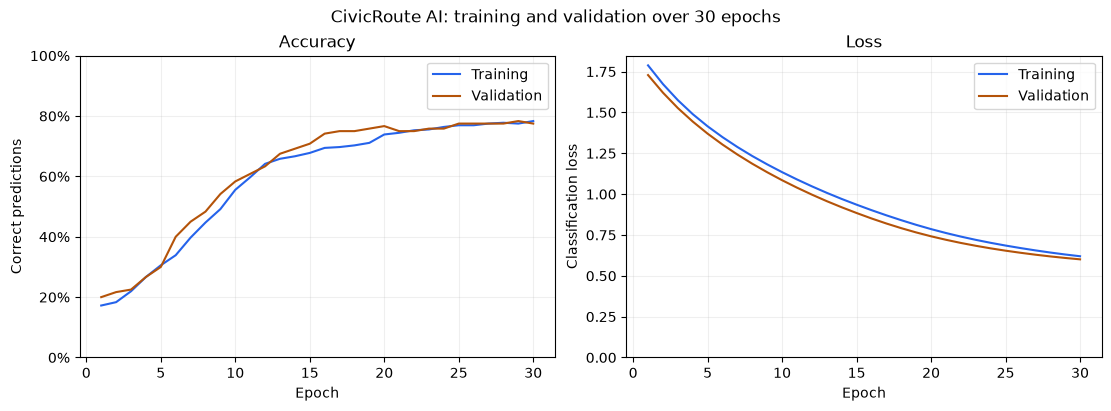

In [9]:
%matplotlib inline
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
epochs = history_df.index

axes[0].plot(epochs, history_df["accuracy"], label="Training", color="#2563eb")
axes[0].plot(epochs, history_df["val_accuracy"], label="Validation", color="#b45309")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Correct predictions")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

axes[1].plot(epochs, history_df["loss"], label="Training", color="#2563eb")
axes[1].plot(epochs, history_df["val_loss"], label="Validation", color="#b45309")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Classification loss")
axes[1].set_ylim(bottom=0)

for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend()

fig.suptitle(f"CivicRoute AI: training and validation over {len(history_df)} epochs")
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


### 3.5 Evaluate the prototype

Report overall test accuracy and produce a confusion matrix. These are the main outputs you will use when explaining one strength, one weakness or risky error, and what should happen next.


Test accuracy: 75.0%
Correct predictions: 90 of 120
Test loss: 0.6450


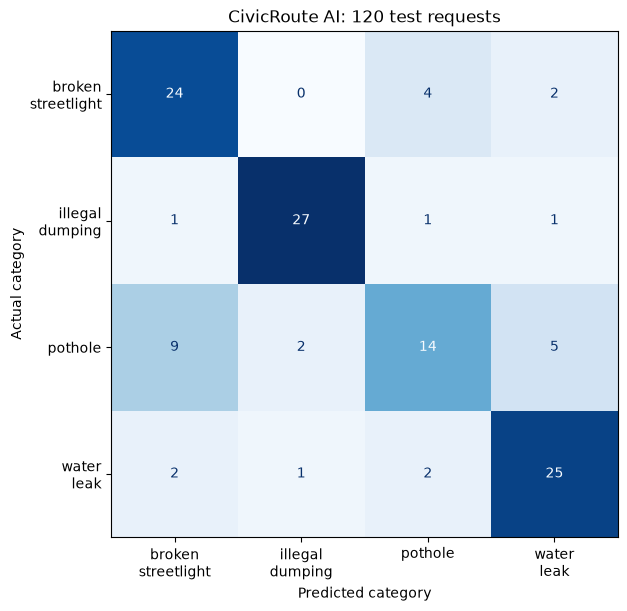

In [10]:
import json

# Evaluate the fixed model on the held-out test set.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_probabilities = model.predict(X_test, verbose=0)
predicted_ids = np.argmax(test_probabilities, axis=1)

cm = confusion_matrix(
    y_test, predicted_ids, labels=np.arange(len(class_names))
)
correct_predictions = int(np.trace(cm))
print(f"Test accuracy: {test_accuracy:.1%}")
print(f"Correct predictions: {correct_predictions} of {len(y_test)}")
print(f"Test loss: {test_loss:.4f}")

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[name.replace("_", "\n") for name in class_names],
).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set(
    title=f"CivicRoute AI: {len(y_test)} test requests",
    xlabel="Predicted category",
    ylabel="Actual category",
)
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

pd.DataFrame(
    cm,
    index=pd.Index(class_names, name="actual_category"),
    columns=pd.Index(class_names, name="predicted_category"),
).to_csv(OUTPUT_DIR / "confusion_matrix.csv")

test_predictions = pd.DataFrame({
    "request_id": df.loc[test_df.index, "request_id"].to_numpy(),
    "actual_category": [class_names[value] for value in y_test],
    "predicted_category": [class_names[value] for value in predicted_ids],
})
test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

metrics = {
    "random_seed": RANDOM_SEED,
    "hidden_units": 16,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "training_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "input_columns": prepared_columns,
    "class_names": class_names,
    "final_training_accuracy": float(history_df["accuracy"].iloc[-1]),
    "final_validation_accuracy": float(history_df["val_accuracy"].iloc[-1]),
    "final_training_loss": float(history_df["loss"].iloc[-1]),
    "final_validation_loss": float(history_df["val_loss"].iloc[-1]),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "correct_test_predictions": correct_predictions,
    "confusion_matrix": cm.tolist(),
    "tensorflow_version": tf.__version__,
    "keras_version": keras.__version__,
}
(OUTPUT_DIR / "evaluation.json").write_text(json.dumps(metrics, indent=2) + "\n")
model.save(OUTPUT_DIR / "civicroute_model.keras")


## Step 4: Interpretation and explainability notes

No XAI library needs to be implemented in this notebook. Use the evidence above to prepare for the video discussion.

Record brief notes for yourself:

1. What do the training and validation results suggest about the model?
2. What does the test result and confusion matrix reveal?
3. What is one useful strength and one important weakness or risky error?
4. Compare one **model-agnostic** explanation method and one **model-specific** explanation method from the course.
5. Which explanation approach is more appropriate for this tabular prototype, and why?
6. What additional evidence or improvement would make you more confident in CivicRoute AI?


## Step 5 reminder: Graph-based modelling and GNNs

**No graph or GNN implementation is required.**

Prepare to explain in the video:

- useful node types;
- useful relationships or edges;
- one question a graph representation could help investigate;
- where a GNN could add value if CivicRoute AI became more relationship-driven; and
- whether a GNN is justified for the current prototype or should be considered later.


## Step 6 reminder: GitHub evidence

Keep this notebook and the selected supporting evidence in your GitHub repository.

Your video must demonstrate the GitHub workflow required by the assessment brief, including:

- a meaningful local change followed by add, commit and push;
- a remote change followed by pull;
- a branch-and-merge workflow;
- repository history; and
- how the README and file structure support reproducibility.

Commit meaningful milestones as you work rather than making one large final commit.


## Final recommendation notes

Before recording the final part of your video, return to the central question:

**Based on the evidence from your small prototype, what does CivicRoute AI appear capable of, what should be treated with caution, and what should the council do next?**

Base your recommendation on the evidence produced in this notebook rather than on accuracy alone.
